<a href="https://colab.research.google.com/github/finnydaniel24/Customer-Churn-Prediction/blob/main/Classification_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🍎 Image Classification with Convolutional Neural Networks (CNN)

## Apple Leaf Disease Detection

In this notebook we train a **Convolutional Neural Network (CNN)** to classify apple leaf images as
healthy or diseased.  The task is a standard **multi-class image classification** problem.

**Dataset:** Apple Leaf Disease Dataset — available on Kaggle:
[https://www.kaggle.com/datasets/nirmalsankalana/apple-leaf-disease-dataset](https://www.kaggle.com/datasets/nirmalsankalana/apple-leaf-disease-dataset)

---

### 🗺️ Notebook Structure

| Step | Section | Description |
|------|---------|-------------|
| 1 | **Initialisation** | Import libraries & define hyper-parameters |
| 2 | **Data Loading** | Download, split, and inspect the dataset |
| 3 | **Model Definition** | Build and compile the CNN architecture |
| 4 | **Training** | Fit the model with early stopping & checkpointing |
| 5 | **Results Analysis** | Learning curves, confusion matrix, error inspection |

---

### 🎯 Learning Objectives

1. Understand the end-to-end workflow of a machine-learning pipeline.
2. Improve model performance by tuning the **hyper-parameters** (§ 1.2) and the **architecture** (§ 3.1).
3. Interpret and comment on the results of your best model.



---
## 1. Initialisation

This section gathers **all imports** in one place and **centralises key parameters** so they are
easy to find and modify.  Keeping hyper-parameters at the top of a notebook is a best practice:
it avoids hunting through hundreds of lines of code every time you want to run an experiment.


### 1.1 Library Imports

Python is a modular language — we rely on specialised packages rather than re-implementing
everything from scratch.  Here is what each package does:

| Package | Role |
|---------|------|
| `kagglehub` | Download datasets directly from Kaggle |
| `os`, `glob` | File system navigation and pattern matching |
| `numpy` | Numerical arrays — the backbone of all data manipulation |
| `matplotlib` | Plotting (training curves, sample images, …) |
| `cv2` | OpenCV — fast image processing (resize, colour conversion, …) |
| `skimage` | Scikit-image — additional image I/O utilities |
| `tqdm` | Progress bars for loops |
| `sklearn` | Confusion matrix, train/test split |
| `seaborn` | Statistical data visualisation (heatmaps, …) |
| `tensorflow / keras` | Deep-learning framework — model building, training, saving |


In [1]:
# ── Standard library ────────────────────────────────────────────────────────
import os                          # operating-system interface (paths, directories)
import glob                        # Unix-style pathname pattern expansion

# ── Data handling ────────────────────────────────────────────────────────────
import numpy as np                 # numerical arrays
import numpy.matlib                # matrix utilities (used in confusion-matrix normalisation)

# ── Image I/O & processing ───────────────────────────────────────────────────
import cv2                         # OpenCV: image resize, colour operations
from skimage import io             # scikit-image: read images from disk

# ── Progress & display ───────────────────────────────────────────────────────
from tqdm import tqdm              # progress bar for long loops
import matplotlib.pyplot as plt    # plotting
import seaborn as sns              # heatmaps and statistical plots

# ── Dataset download ─────────────────────────────────────────────────────────
import kagglehub                   # Kaggle Hub API

# ── Machine-learning utilities ───────────────────────────────────────────────
from sklearn import metrics                          # evaluation metrics
from sklearn.model_selection import train_test_split # dataset splitting

# ── Keras / TensorFlow ───────────────────────────────────────────────────────
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Conv2D,        # 2-D convolutional layer
    MaxPooling2D,  # spatial down-sampling
    Flatten,       # reshape 3-D feature maps → 1-D vector
    Dense,         # fully-connected (linear) layer
    Dropout        # regularisation: randomly drops neuron connections
)
from tensorflow.keras.utils import to_categorical    # one-hot encode class labels
from tensorflow.keras.callbacks import (
    ModelCheckpoint, # save the best model during training
    EarlyStopping    # stop training when validation loss stops improving
)
from tensorflow.keras.optimizers import Adam         # adaptive gradient-descent optimiser

print("✅ All libraries imported successfully.")


✅ All libraries imported successfully.


### 1.2 Hyper-parameter Configuration

> ⚙️ **These are the knobs you turn first when trying to improve performance.**
> All key parameters live here so you never have to dig inside function bodies.

| Parameter | Current value | What it controls |
|-----------|--------------|-----------------|
| `IMG_SIZE` | `(128, 128)` | Spatial resolution of every input image |
| `EPOCHS` | `1000` | Maximum number of training iterations (early stopping will cut this short) |
| `BATCH_SIZE` | `128` | Number of images processed in one gradient-update step |
| `LEARNING_RATE` | `0.003` | Step size for gradient descent — too large → divergence, too small → slow |
| `CHECKPOINT_PATH` | `'Model.h5'` | File path where the best model weights are saved |
| `EARLY_STOP_PATIENCE` | `10` | How many epochs without improvement before training stops |


In [2]:
# ── Image dimensions ─────────────────────────────────────────────────────────
IMG_SIZE = (128, 128)   # (height, width) — all images will be resized to this shape.
                        # Larger → more detail but more memory & compute.

# ── Training schedule ────────────────────────────────────────────────────────
EPOCHS = 1000           # Upper bound on training epochs.
                        # Early stopping (§ 3.3) will typically halt training well before this.

BATCH_SIZE = 32        # Mini-batch size.
                        # Common values: 32, 64, 128, 256.
                        # Smaller → noisier but sometimes better generalisation;
                        # Larger → faster but needs more GPU memory.

LEARNING_RATE = 0.003   # Initial learning rate for the Adam optimiser.
                        # If training is unstable, try 10× smaller (0.0003).

# ── Persistence ──────────────────────────────────────────────────────────────
CHECKPOINT_PATH = 'Model.h5'   # Best model will be saved here during training.

# ── Early stopping ───────────────────────────────────────────────────────────
EARLY_STOP_PATIENCE = 10       # Number of epochs with no val_loss improvement
                               # after which training is stopped automatically.

print("✅ Hyper-parameters configured:")
print(f"   Image size      : {IMG_SIZE}")
print(f"   Max epochs      : {EPOCHS}")
print(f"   Batch size      : {BATCH_SIZE}")
print(f"   Learning rate   : {LEARNING_RATE}")
print(f"   Patience        : {EARLY_STOP_PATIENCE}")
print(f"   Checkpoint path : {CHECKPOINT_PATH}")


✅ Hyper-parameters configured:
   Image size      : (128, 128)
   Max epochs      : 1000
   Batch size      : 32
   Learning rate   : 0.003
   Patience        : 10
   Checkpoint path : Model.h5


---
## 2. Data Loading

A clean, well-understood dataset is the foundation of any successful model.
This section covers:
1. Defining a reusable loading function.
2. Downloading the dataset from Kaggle.
3. Verifying quantities, shapes, and pixel value ranges.
4. Visualising sample images so we can *see* what the model will learn from.


### 2.1 Data-Loading Function

The function below reads images from disk, resizes them to a uniform resolution,
assigns integer labels, normalises pixel values to [0, 1], and splits the dataset
into three independent subsets:

```
Full dataset
├── 70 % → Training set   (X_train, y_train)
├── 15 % → Validation set (X_val,   y_val)    ← used to monitor training
└── 15 % → Test set       (X_test,  y_test)   ← never seen during training
```

> ⚠️ **Why three splits?**
> - **Train** — the model *learns* from these examples (weights are updated here).
> - **Validation** — used to *tune* hyper-parameters and trigger early stopping.
>   The model never trains on validation data, but we use its loss to make decisions.
> - **Test** — completely held-out set used only *once* at the very end to report
>   unbiased final performance.  If you tune the model based on test results, the
>   reported accuracy becomes overly optimistic (data leakage).


In [3]:
def load_data(directory, classes, img_size):
    """
    Load, resize, normalise and split an image dataset.

    Parameters
    ----------
    directory : str
        Root folder containing one sub-folder per class.
    classes : list[str]
        Ordered list of class folder names.
    img_size : tuple[int, int]
        Target (width, height) to which every image is resized.

    Returns
    -------
    (X_train, y_train, X_val, y_val, X_test, y_test)
        Numpy arrays of normalised images and one-hot labels.
    """
    X = []   # will hold image pixel arrays
    y = []   # will hold integer class indices

    # ── Collect file paths for each class ────────────────────────────────────
    # glob.glob returns a list of all file paths matching a pattern.
    # We look for .JPG files inside each class sub-folder.
    paths = [glob.glob(f'{directory}/{cls}/*.jpg') for cls in classes]

    # ── Read and resize images ───────────────────────────────────────────────
    for class_idx, (cls, class_paths) in enumerate(zip(classes, paths)):
        print(f"  Loading class '{cls}' ({len(class_paths)} images)…")
        for img_path in tqdm(class_paths, desc=f"  {cls}"):
            img = io.imread(img_path)                # read image → (H, W, 3) uint8
            img = cv2.resize(img, img_size)          # resize to uniform shape
            X.append(img)
            y.append(class_idx)                      # store integer label

    # ── Convert to numpy arrays ──────────────────────────────────────────────
    X = np.array(X, dtype=np.float32) / 255.0
    # Division by 255 normalises uint8 pixel values (0–255) to float32 (0.0–1.0).
    # Neural networks converge faster and more reliably on normalised inputs.

    y = np.array(y)

    # ── One-hot encode labels ────────────────────────────────────────────────
    # Example with 3 classes: class 1 → [0, 1, 0]
    # The final Dense layer will output one probability per class, so labels
    # must have the same shape.
    y = to_categorical(y, num_classes=len(classes))

    # ── Train / (Val + Test) split — 70 % / 30 % ────────────────────────────
    X_train, X_testval, y_train, y_testval = train_test_split(
        X, y, test_size=0.30, random_state=42, stratify=y
    )
    # stratify=y ensures each split has the same class distribution as the full set.

    # ── Val / Test split — 50 % / 50 % of the 30 % → 15 % / 15 % ───────────
    X_test, X_val, y_test, y_val = train_test_split(
        X_testval, y_testval, test_size=0.50, random_state=42, stratify=y_testval
    )

    return X_train, y_train, X_val, y_val, X_test, y_test

print("✅ load_data() function defined.")


✅ load_data() function defined.


### 2.2 Download and Split the Dataset

The dataset is downloaded from Kaggle via `kagglehub`.  The first run requires
valid Kaggle credentials (`~/.kaggle/kaggle.json`); subsequent runs use a local cache.


In [4]:
# ── Download from Kaggle ─────────────────────────────────────────────────────
print("📥 Downloading dataset from Kaggle…")
path_clas = kagglehub.dataset_download("nirmalsankalana/apple-leaf-disease-dataset")
path_clas = path_clas + os.sep + 'data'  # dive into the 'data' sub-folder

# ── Discover class names from folder structure ───────────────────────────────
# Each sub-folder in 'data/' corresponds to one class.
names = sorted(os.listdir(path_clas))   # sort for reproducibility
print(f"\n📂 Dataset root : {path_clas}")
print(f"🏷️  Classes found ({len(names)}) : {names}")

# ── Load, resize, normalise, and split ───────────────────────────────────────
print("\n⏳ Loading images…")
X_train, y_train, X_val, y_val, X_test, y_test = load_data(path_clas, names, IMG_SIZE)
print("\n✅ Dataset loaded and split.")


📥 Downloading dataset from Kaggle…
Using Colab cache for faster access to the 'apple-leaf-disease-dataset' dataset.

📂 Dataset root : /kaggle/input/apple-leaf-disease-dataset/data
🏷️  Classes found (3) : ['healthy', 'rust', 'scab']

⏳ Loading images…
  Loading class 'healthy' (516 images)…


  healthy: 100%|██████████| 516/516 [00:17<00:00, 29.11it/s]


  Loading class 'rust' (622 images)…


  rust: 100%|██████████| 622/622 [00:20<00:00, 29.78it/s]


  Loading class 'scab' (592 images)…


  scab: 100%|██████████| 592/592 [00:19<00:00, 31.05it/s]



✅ Dataset loaded and split.


### 2.3 Dataset Inspection

Before training any model, always sanity-check:
- **Counts** — are the splits the right size?
- **Shapes** — are images the expected resolution and channel count?
- **Value range** — did normalisation work? (should be [0, 1])
- **Class balance** — are classes roughly equally represented?
- **Visual check** — do the images actually look correct?


  Training   samples :   1211
  Validation samples :    260
  Test       samples :    259
  Total              :   1730
  Input  shape  (H, W, C) : (128, 128, 3)
  Output shape  (classes) : (3,)
  Pixel value range — min: 0.0000  max: 1.0000
  (expected after normalisation: 0.0 – 1.0)


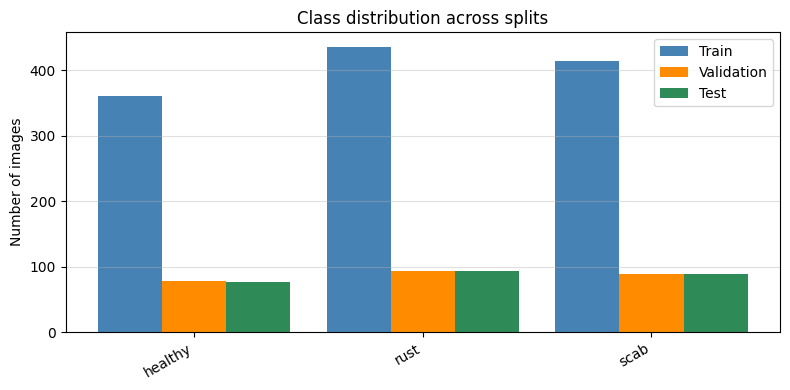

In [5]:
# ── Counts and shapes ────────────────────────────────────────────────────────
print("=" * 55)
print(f"  Training   samples : {X_train.shape[0]:>6}")
print(f"  Validation samples : {X_val.shape[0]:>6}")
print(f"  Test       samples : {X_test.shape[0]:>6}")
print(f"  Total              : {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]:>6}")
print("=" * 55)
print(f"  Input  shape  (H, W, C) : {X_train.shape[1:]}")
print(f"  Output shape  (classes) : {y_train.shape[1:]}")
print("=" * 55)
print(f"  Pixel value range — min: {X_train.min():.4f}  max: {X_train.max():.4f}")
print("  (expected after normalisation: 0.0 – 1.0)")
print("=" * 55)

# ── Class distribution bar chart ─────────────────────────────────────────────
counts_train = y_train.sum(axis=0).astype(int)
counts_val   = y_val.sum(axis=0).astype(int)
counts_test  = y_test.sum(axis=0).astype(int)

x = np.arange(len(names))
width = 0.28

fig, ax = plt.subplots(figsize=(max(8, len(names) * 1.5), 4))
ax.bar(x - width, counts_train, width, label='Train',      color='steelblue')
ax.bar(x,         counts_val,   width, label='Validation', color='darkorange')
ax.bar(x + width, counts_test,  width, label='Test',       color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=30, ha='right')
ax.set_ylabel("Number of images")
ax.set_title("Class distribution across splits")
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()


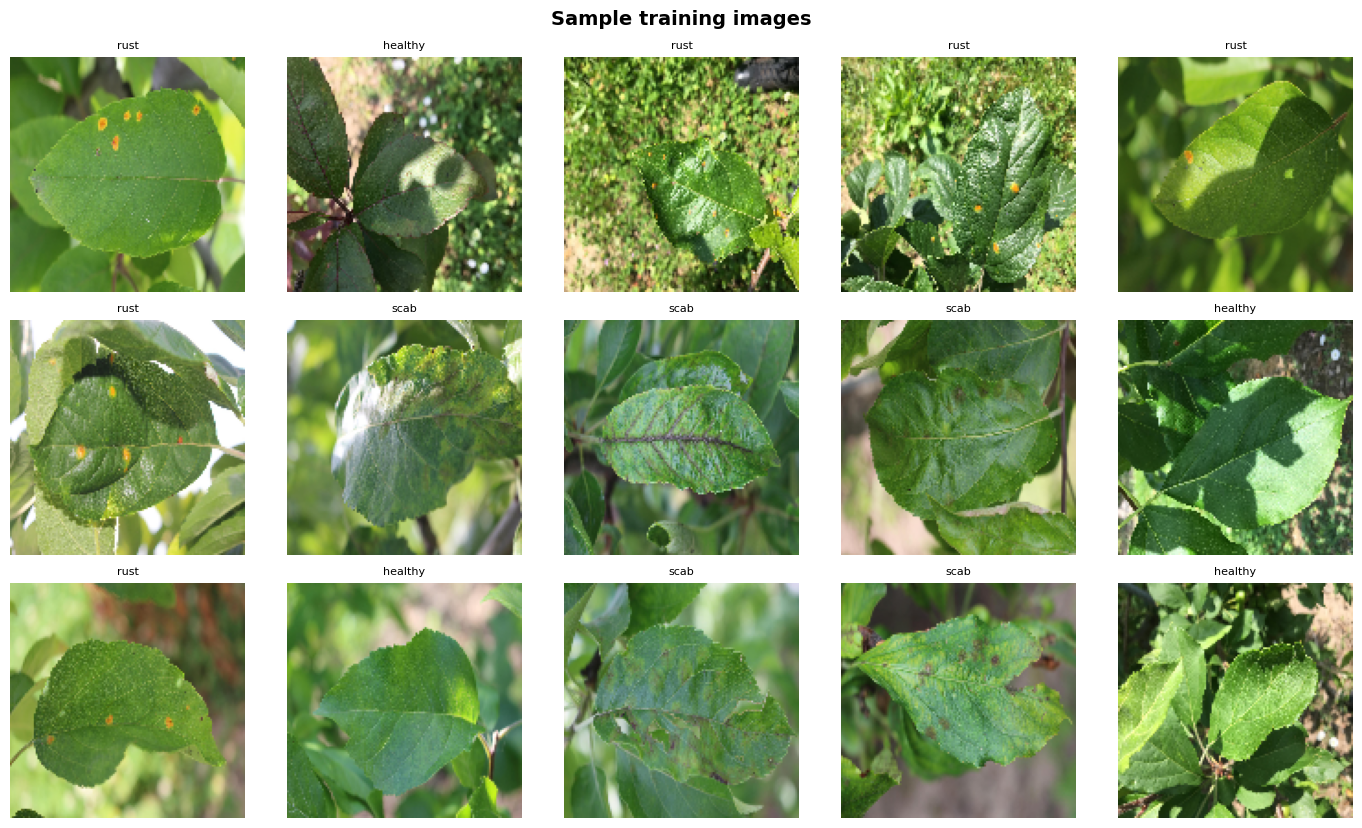

In [6]:
# ── Visual sample grid ───────────────────────────────────────────────────────
# Displaying a few training images helps verify that:
#   - images are correctly loaded and decoded (colours look right)
#   - labels match the visual content
#   - resizing did not distort the images too badly

n_cols = 5
n_rows = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.8, n_rows * 2.8))
fig.suptitle("Sample training images", fontsize=14, fontweight='bold')

np.random.seed(0)
sample_idx = np.random.choice(len(X_train), n_rows * n_cols, replace=False)

for ax, idx in zip(axes.ravel(), sample_idx):
    ax.imshow(X_train[idx])
    label = names[np.argmax(y_train[idx])]
    ax.set_title(label, fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()


---
## 3. Model Preparation

### 3.1 CNN Architecture

A **Convolutional Neural Network** processes images through a series of learned filters
that detect progressively more abstract features:

```
Input image (128×128×3)
        │
   ┌────▼────┐
   │  Conv   │  → detect low-level features (edges, colours)
   │ MaxPool │  → halve spatial dimensions
   └────┬────┘
        │ (×3 more conv blocks, with increasing filter counts)
   ┌────▼────┐
   │ Flatten │  → reshape 3-D feature maps to a 1-D vector
   │ Dropout │  → regularisation
   │  Dense  │  → learn high-level combinations
   │ Dropout │
   │  Dense  │  → one output neuron per class (softmax → probabilities)
   └─────────┘
```

**Key design choices explained:**

| Layer | Parameter | Effect |
|-------|-----------|--------|
| `Conv2D(32, 5×5)` | 32 filters | Learns 32 different feature detectors |
| `MaxPooling2D(2,2)` | stride 2 | Halves H and W → fewer parameters |
| Increasing filters (32→64→128) | — | Deeper layers capture more complex patterns |
| `Dropout(0.2)` | rate=0.2 | Randomly zeros 20 % of connections → reduces overfitting |
| `Dense(128, relu)` | 128 units | Fully-connected decision layer |
| `Dense(N, softmax)` | N = #classes | Outputs a probability distribution over classes |

> 🛠️ **Things to try:**
> - Add or remove Conv+Pool blocks.
> - Increase/decrease the number of filters.
> - Change the Dropout rate (0.1 – 0.5).
> - Replace the large Dense layer with a smaller or larger one.


In [7]:
# ── Build the model ──────────────────────────────────────────────────────────
model = Sequential([

    # ── Block 1: detect simple edges and colour gradients ────────────────────
    Conv2D(32, (5, 5), activation='relu',
           input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    # • 32 filters of size 5×5
    # • ReLU activation: f(x) = max(0, x) — introduces non-linearity
    # • input_shape must be specified for the first layer only
    MaxPooling2D(2, 2),
    # • Takes the maximum value in each 2×2 window
    # • Reduces spatial size by 2 → (62×62 after a 5×5 conv on 128×128)

    # ── Block 2: detect more complex textures ────────────────────────────────
    Conv2D(64, (5, 5), activation='relu'),
    MaxPooling2D(2, 2),

    # ── Block 3: detect shapes and parts ─────────────────────────────────────
    Conv2D(128, (5, 5), activation='relu'),
    MaxPooling2D(2, 2),

    # ── Block 4: high-level semantic features ────────────────────────────────
    Conv2D(128, (5, 5), activation='relu'),
    MaxPooling2D(2, 2),

    # ── Transition: feature maps → vector ────────────────────────────────────
    Flatten(),
    # • Reshapes (H', W', C') → (H'*W'*C',) so Dense layers can process it

    # ── Classifier head ──────────────────────────────────────────────────────
    Dropout(0.2),
    # • Randomly drops 20 % of units at each training step → regularisation
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(len(names), activation='softmax'),
    # • One output per class; softmax ensures outputs sum to 1 (probability distribution)
])

print("✅ Model architecture defined.")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Model architecture defined.


### 3.2 Model Compilation

Before training we must specify:
- **Optimiser** — the algorithm that updates weights (here: Adam, an adaptive gradient-descent method).
- **Loss function** — what the optimiser minimises (here: categorical cross-entropy, standard for multi-class classification).
- **Metric** — what we track during training (here: accuracy, which is human-interpretable).


In [8]:
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    # Adam: adapts the learning rate per-parameter using running statistics of
    # gradients — typically converges faster than plain SGD.
    # See: https://arxiv.org/abs/1412.6980

    loss='categorical_crossentropy',
    # Standard loss for multi-class classification with one-hot labels.
    # Equivalent to the negative log-likelihood of the true class.

    metrics=['accuracy']
    # Fraction of correctly classified samples — easy to interpret, but
    # can be misleading for imbalanced datasets (check the confusion matrix!).
)

print("✅ Model compiled.")
print(f"   Optimiser     : Adam  (lr={LEARNING_RATE})")
print(f"   Loss function : categorical_crossentropy")
print(f"   Metric        : accuracy")


✅ Model compiled.
   Optimiser     : Adam  (lr=0.003)
   Loss function : categorical_crossentropy
   Metric        : accuracy


### 3.3 Training Callbacks

Two optional but strongly recommended callbacks:

**EarlyStopping** — stops training automatically when `val_loss` has not improved
for `patience` consecutive epochs.  This prevents wasted compute *and* overfitting.

**ModelCheckpoint** — saves the model weights whenever `val_loss` reaches a new minimum.
This ensures we always keep the *best* model, even if later epochs are worse.


In [9]:
# ── Early Stopping ───────────────────────────────────────────────────────────
early = EarlyStopping(
    monitor='val_loss',           # watch validation loss
    patience=EARLY_STOP_PATIENCE, # stop after this many epochs with no improvement
    verbose=1,                    # print a message when stopping
    mode='min',                   # lower val_loss is better
    restore_best_weights=True     # revert to best weights when stopped
)

# ── Model Checkpoint ─────────────────────────────────────────────────────────
checkpoint = ModelCheckpoint(
    CHECKPOINT_PATH,
    monitor='val_loss',           # save when val_loss improves
    verbose=0,
    save_best_only=True,          # keep only the single best model on disk
    mode='min'
)

print("✅ Callbacks configured:")
print(f"   EarlyStopping   — patience={EARLY_STOP_PATIENCE}, monitor=val_loss")
print(f"   ModelCheckpoint — saving best model to '{CHECKPOINT_PATH}'")


✅ Callbacks configured:
   EarlyStopping   — patience=10, monitor=val_loss
   ModelCheckpoint — saving best model to 'Model.h5'


### 3.4 Architecture Summary

`model.summary()` prints a layer-by-layer breakdown: output shape and parameter count.
The **total parameter count** gives a rough sense of model capacity.


In [10]:
model.summary()

# Total parameters = all weights + biases across every layer.
# Rule of thumb: you need >>10× more training samples than parameters to avoid
# overfitting without strong regularisation.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 124, 124, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 58, 58, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 128)      │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 931,011 (3.55 MB)

 Trainable params: 931,011 (3.55 MB)

 Non-trainable params: 0 (0.00 B)

---
## 4. Training

Everything is in place — the following cell launches training.

> ⚠️ **Important:** To restart training from scratch (e.g., after changing the architecture),
> you **must re-run Section 3.2** (compilation) to re-initialise the weights.
> Simply re-running the `.fit()` cell continues from the current weights.

> ⏱️ Training time depends heavily on GPU availability.  On CPU, each epoch may
> take several minutes.  Early stopping will typically halt training well before
> `EPOCHS = 1000`.


In [11]:
history = model.fit(
    X_train, y_train,               # training data
    validation_data=(X_val, y_val), # validation data (monitored by callbacks)
    epochs=EPOCHS,                  # maximum number of epochs
    batch_size=BATCH_SIZE,          # images per gradient-update step
    verbose=1,                      # print progress per epoch
    callbacks=[checkpoint, early]   # early stopping + model saving
)

print("\n✅ Training complete.")


Epoch 1/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.3477 - loss: 1.8437

38/38 ━━━━━━━━━━━━━━━━━━━━ 16s 219ms/step - accuracy: 0.3452 - loss: 1.3314 - val_accuracy: 0.3423 - val_loss: 1.0964
Epoch 2/1000
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3481 - loss: 1.0923

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.3427 - loss: 1.0966 - val_accuracy: 0.3577 - val_loss: 1.0963
Epoch 3/1000
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3165 - loss: 1.0976

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.3369 - loss: 1.0969 - val_accuracy: 0.3577 - val_loss: 1.0962
Epoch 4/1000
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3634 - loss: 1.0954

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.3600 - loss: 1.0959 - val_accuracy: 0.3577 - val_loss: 1.0960
Epoch 5/1000
36/38 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3600 - loss: 1.0984

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.3600 - loss: 1.0963 - val_accuracy: 0.3577 - val_loss: 1.0959
Epoch 6/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.3600 - loss: 1.0965 - val_accuracy: 0.3577 - val_loss: 1.0959
Epoch 7/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.3600 - loss: 1.0963 - val_accuracy: 0.3577 - val_loss: 1.0959
Epoch 8/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.3600 - loss: 1.0960 - val_accuracy: 0.3577 - val_loss: 1.0960
Epoch 9/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.3600 - loss: 1.0958 - val_accuracy: 0.3577 - val_loss: 1.0959
Epoch 10/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.3600 - loss: 1.0963 - val_accuracy: 0.3577 - val_loss: 1.0960
Epoch 11/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.3287 - loss: 1.0968 - val_accuracy: 0.3577 - val_loss: 1.0959
Epoch 12/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.3600 - loss: 1.0962 - val_accuracy: 0.35

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.3600 - loss: 1.0959 - val_accuracy: 0.3577 - val_loss: 1.0959
Epoch 15/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.3600 - loss: 1.0961 - val_accuracy: 0.3577 - val_loss: 1.0959
Epoch 16/1000
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3581 - loss: 1.0932

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.3600 - loss: 1.0961 - val_accuracy: 0.3577 - val_loss: 1.0959
Epoch 17/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.3600 - loss: 1.0960 - val_accuracy: 0.3577 - val_loss: 1.0959
Epoch 18/1000
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3559 - loss: 1.0969

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.3600 - loss: 1.0959 - val_accuracy: 0.3577 - val_loss: 1.0959
Epoch 19/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.3600 - loss: 1.0960 - val_accuracy: 0.3577 - val_loss: 1.0960
Epoch 20/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.3600 - loss: 1.0961 - val_accuracy: 0.3577 - val_loss: 1.0959
Epoch 21/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.3600 - loss: 1.0961 - val_accuracy: 0.3577 - val_loss: 1.0959
Epoch 22/1000
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3692 - loss: 1.0953

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.3600 - loss: 1.0958 - val_accuracy: 0.3577 - val_loss: 1.0959
Epoch 23/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.3600 - loss: 1.0962 - val_accuracy: 0.3577 - val_loss: 1.0959
Epoch 24/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.3600 - loss: 1.0955 - val_accuracy: 0.3577 - val_loss: 1.0959
Epoch 25/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.3600 - loss: 1.0959 - val_accuracy: 0.3577 - val_loss: 1.0960
Epoch 26/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.3600 - loss: 1.0960 - val_accuracy: 0.3577 - val_loss: 1.0959
Epoch 27/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.3600 - loss: 1.0960 - val_accuracy: 0.3577 - val_loss: 1.0959
Epoch 28/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.3600 - loss: 1.0959 - val_accuracy: 0.3577 - val_loss: 1.0959
Epoch 29/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.3600 - loss: 1.0959 - val_accuracy: 

---
## 5. Results Analysis

A single accuracy number is rarely enough.  This section uses **four complementary tools**
to understand *how well* the model has learned and *where* it still struggles.


### 5.1 Learning Curves

Learning curves plot **loss** and **accuracy** over epochs for both the training and
validation sets.  They are the primary diagnostic tool for identifying:

| Pattern | Symptom | Remedy |
|---------|---------|--------|
| **Underfitting** | Both curves plateau at poor values; no convergence | Larger model, more epochs, lower learning rate |
| **Overfitting** | Training keeps improving but validation diverges | More dropout, data augmentation, early stopping |
| **Good fit** | Both curves converge to similar, low-loss values | ✔ |

📚 Learn more:
- [Learning curves explained](https://machinelearningmastery.com/learning-curves-for-diagnosing-machine-learning-model-performance)
- [Video tutorial](https://www.youtube.com/watch?v=OPF1GEEzWqM&t=21s)


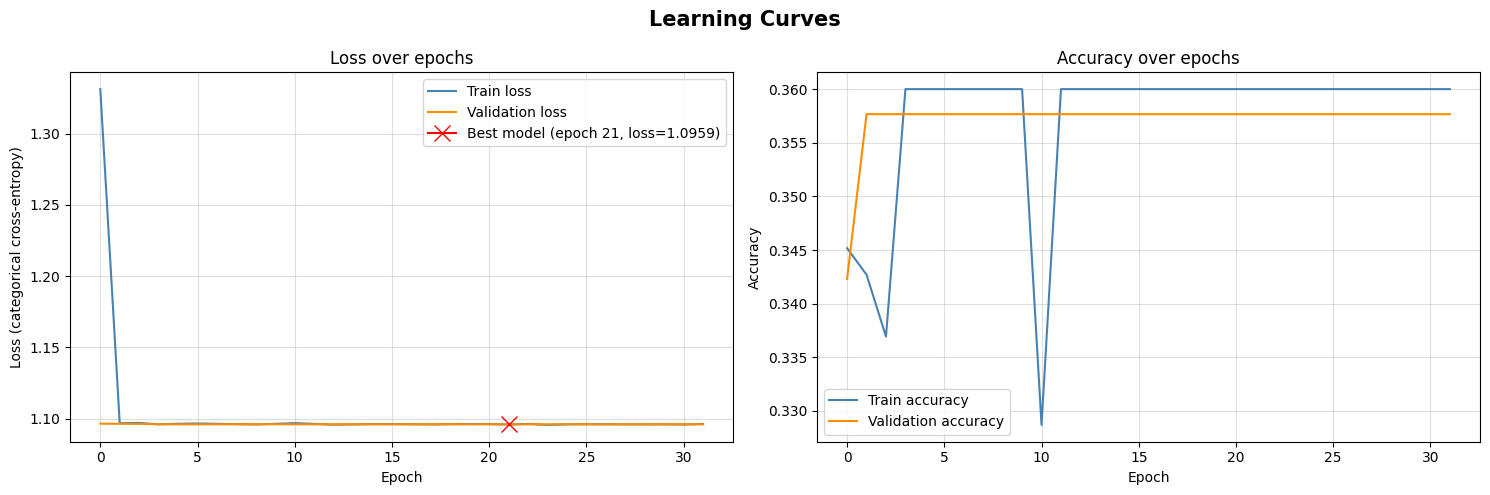

Best validation loss   : 1.0959  (epoch 21)
Best validation accuracy (same epoch) : 0.3577


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Learning Curves", fontsize=15, fontweight='bold')

# ── Loss curves ───────────────────────────────────────────────────────────────
best_epoch = np.argmin(history.history['val_loss'])
best_val_loss = np.min(history.history['val_loss'])

ax1.plot(history.history['loss'],     label='Train loss',      color='steelblue')
ax1.plot(history.history['val_loss'], label='Validation loss', color='darkorange')
ax1.plot(best_epoch, best_val_loss,
         marker='x', markersize=12, color='red',
         label=f'Best model (epoch {best_epoch}, loss={best_val_loss:.4f})')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (categorical cross-entropy)')
ax1.set_title('Loss over epochs')
ax1.legend()
ax1.grid(alpha=0.4)

# ── Accuracy curves ───────────────────────────────────────────────────────────
ax2.plot(history.history['accuracy'],     label='Train accuracy',      color='steelblue')
ax2.plot(history.history['val_accuracy'], label='Validation accuracy', color='darkorange')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy over epochs')
ax2.legend()
ax2.grid(alpha=0.4)

plt.tight_layout()
plt.show()

print(f"Best validation loss   : {best_val_loss:.4f}  (epoch {best_epoch})")
print(f"Best validation accuracy (same epoch) : "
      f"{history.history['val_accuracy'][best_epoch]:.4f}")


### 5.2 Load the Best Model

We load the weights saved by `ModelCheckpoint` at the epoch with the lowest validation loss.
This is the model we use for final evaluation — not necessarily the last epoch.


In [13]:
model = load_model(CHECKPOINT_PATH)
print(f"✅ Best model loaded from '{CHECKPOINT_PATH}'.")


✅ Best model loaded from 'Model.h5'.


### 5.3 Test Set Evaluation

The test set has been kept completely unseen throughout training and validation.
This final evaluation gives an **unbiased estimate** of real-world performance.


In [14]:
score = model.evaluate(X_test, y_test, verbose=0)
print("=" * 40)
print(f"  Test Loss     : {score[0]:.4f}")
print(f"  Test Accuracy : {score[1]:.4f}  ({score[1]*100:.1f} %)")
print("=" * 40)


  Test Loss     : 1.0955
  Test Accuracy : 0.3591  (35.9 %)


### 5.4 Confusion Matrix

The **confusion matrix** (CM) is an N×N table (N = number of classes) where:
- **Rows** = ground-truth class
- **Columns** = predicted class
- **Diagonal** = correct predictions (higher is better)
- **Off-diagonal** = errors (which class is confused with which)

We also show the **normalised** CM (values in [0, 1]) so classes of different sizes are comparable.

> 🔍 Look for off-diagonal cells with high values — these reveal the specific class-pairs
> the model struggles to distinguish.


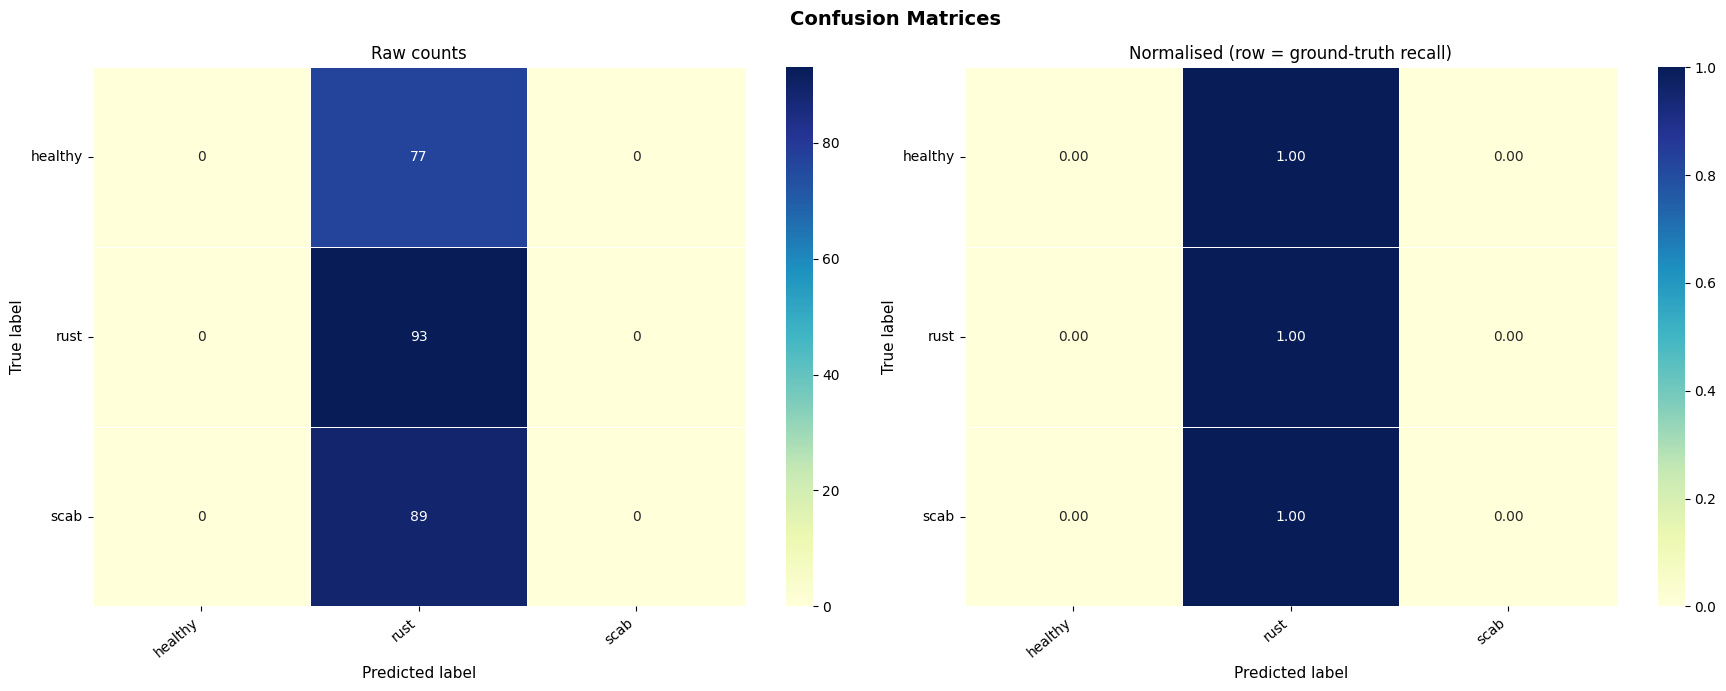


Per-class metrics:
              precision    recall  f1-score   support

     healthy       0.00      0.00      0.00        77
        rust       0.36      1.00      0.53        93
        scab       0.00      0.00      0.00        89

    accuracy                           0.36       259
   macro avg       0.12      0.33      0.18       259
weighted avg       0.13      0.36      0.19       259



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [15]:
# ── Get predictions ──────────────────────────────────────────────────────────
y_pred_proba = model.predict(X_test, verbose=0)  # shape (N, num_classes)
y_pred = y_pred_proba.argmax(axis=1)             # predicted class index
y_true = y_test.argmax(axis=1)                   # ground-truth class index

# ── Compute confusion matrix ─────────────────────────────────────────────────
cm = metrics.confusion_matrix(y_true, y_pred)

# ── Normalise (row-wise: proportion of ground-truth class correctly recalled) ─
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

# ── Plot both side by side ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Confusion Matrices", fontsize=14, fontweight='bold')

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2f'],
    ['Raw counts', 'Normalised (row = ground-truth recall)']
):
    sns.heatmap(
        data, annot=True, fmt=fmt, cmap='YlGnBu',
        xticklabels=names, yticklabels=names,
        ax=ax, linewidths=0.5
    )
    ax.set_xlabel('Predicted label', fontsize=11)
    ax.set_ylabel('True label',      fontsize=11)
    ax.set_title(title)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# ── Per-class metrics ─────────────────────────────────────────────────────────
print("\nPer-class metrics:")
print(metrics.classification_report(y_true, y_pred, target_names=names))


### 5.5 Per-class Prediction Confidence Distribution

Visualise how *confident* the model is when it predicts each class.  A well-calibrated
model should be highly confident when it is correct and uncertain when it is wrong.


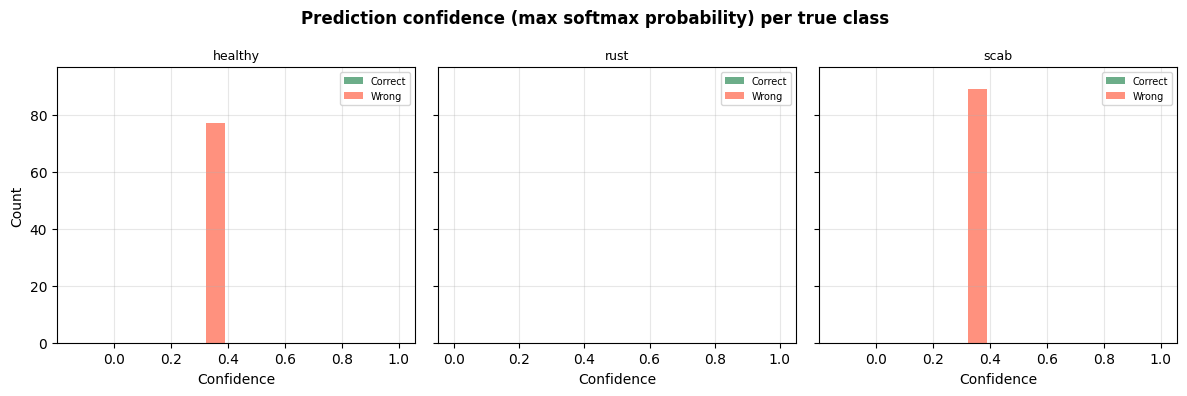

In [16]:
fig, axes = plt.subplots(1, len(names), figsize=(4 * len(names), 4), sharey=True)
fig.suptitle("Prediction confidence (max softmax probability) per true class",
             fontsize=12, fontweight='bold')

for ax, class_idx, class_name in zip(axes, range(len(names)), names):
    mask = (y_true == class_idx)
    if mask.sum() == 0:
        continue
    confidences = y_pred_proba[mask].max(axis=1)
    correct_mask = (y_pred[mask] == class_idx)

    ax.hist(confidences[correct_mask],  bins=15, color='seagreen',    alpha=0.7, label='Correct')
    ax.hist(confidences[~correct_mask], bins=15, color='tomato',      alpha=0.7, label='Wrong')
    ax.set_title(class_name, fontsize=9)
    ax.set_xlabel('Confidence')
    if ax == axes[0]:
        ax.set_ylabel('Count')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 5.6 Individual Error Analysis

Inspect mis-classified images one by one.  This is invaluable for understanding *why*
the model makes mistakes:
- Are the images ambiguous even to a human?
- Is there a systematic pattern (lighting, angle, image quality)?
- Could the label itself be wrong (annotation errors)?

Change `ERROR_INDEX` to browse through different mistakes.


Total errors : 166 / 259  (64.1 % error rate)


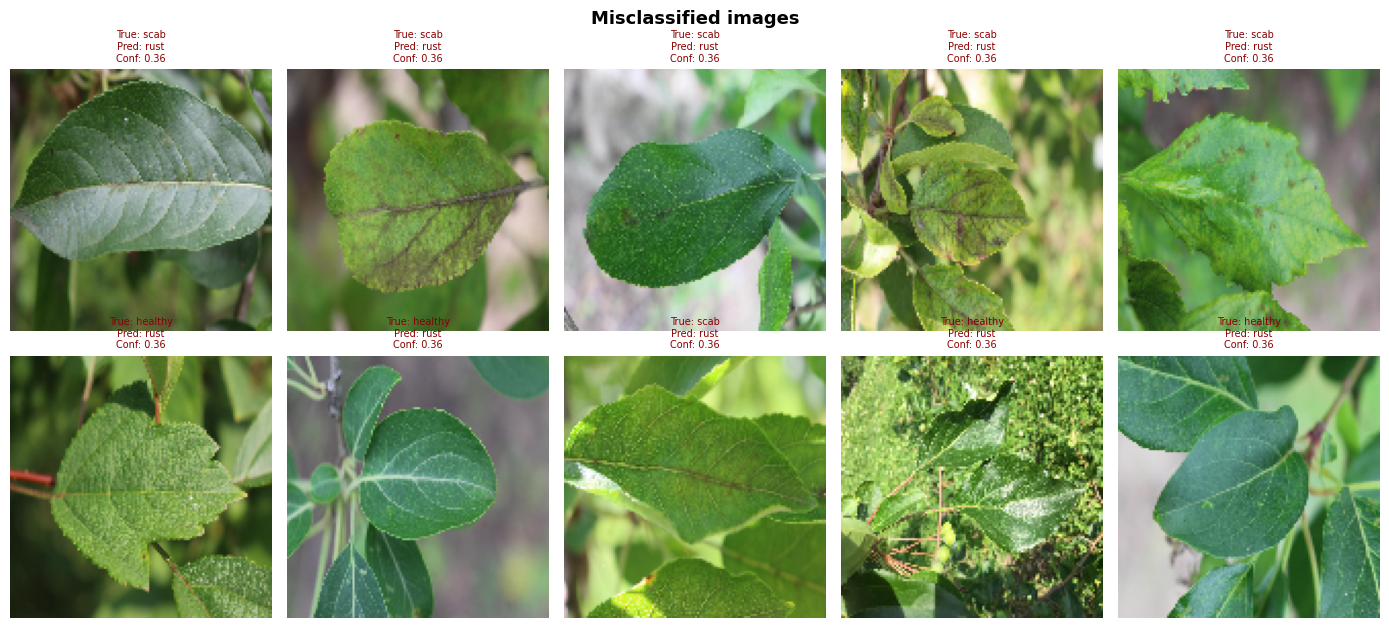

In [17]:
# ── Collect error indices ─────────────────────────────────────────────────────
error_indices = np.where(y_true != y_pred)[0]   # indices of mis-classified samples
print(f"Total errors : {len(error_indices)} / {len(y_true)}  "
      f"({len(error_indices)/len(y_true)*100:.1f} % error rate)")

# ── Display a grid of misclassified images ────────────────────────────────────
n_display = min(10, len(error_indices))   # display up to 10 errors
n_cols = 5
n_rows = (n_display + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(n_cols * 2.8, n_rows * 3.2))
fig.suptitle("Misclassified images", fontsize=13, fontweight='bold')

for ax, err_idx in zip(axes.ravel(), error_indices[:n_display]):
    ax.imshow(X_test[err_idx])
    true_label = names[y_true[err_idx]]
    pred_label = names[y_pred[err_idx]]
    confidence = y_pred_proba[err_idx].max()
    ax.set_title(f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2f}",
                 fontsize=7, color='darkred')
    ax.axis('off')

# Hide unused subplots
for ax in axes.ravel()[n_display:]:
    ax.axis('off')

plt.tight_layout()
plt.show()


---
## 6. Summary and Next Steps

### ✅ What we covered
1. **Built a CNN pipeline** from raw images to class probabilities.
2. **Monitored training** with early stopping and automatic checkpointing.
3. **Evaluated rigorously** using a held-out test set, confusion matrix, and per-class metrics.
4. **Diagnosed errors** visually with confidence histograms and image grids.

### 🚀 Ideas to improve performance
| Technique | Where to apply |
|-----------|---------------|
| **Deeper / wider architecture (hyperparameter tuning)** | Add more Conv blocks, increase filter counts, change the batch size, etc in § 3.1 |
| **Learning-rate schedule** | Add `ReduceLROnPlateau` callback in § 3.3 |
| **Data augmentation** (random flips, rotations, colour jitter) | Add `ImageDataGenerator` in § 2 |
| **Transfer learning** (e.g., MobileNetV2, EfficientNet) | Replace the CNN backbone with a pre-trained model |
| **Weighted loss** (for class imbalance) | Set `class_weight` in `model.fit()` § 4 |
| **Batch Normalisation** after each `Conv2D` | Add `BatchNormalization()` in § 3.1 |
